# DATASET
We downloaded the orignal [kaggle](https://www.kaggle.com/datasets/navaneesh/airbnb/data) set from and saved it as ogdataset.csv.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()



Saving ogdataset.csv to ogdataset.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from google.colab import files
from tensorflow.keras.layers import Dropout
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# PREPROCESSING
## Selecting our features
We used a heatmap to select around 15 features from the 213 available and added some more via intutition and saved in processed_airbnb.csv.

(25458, 213)
   accommodates  bathrooms  bedrooms  beds  cleaning_fee  host_response_rate  \
0             2        1.0       1.0   1.0             1                 100   
1             3        1.0       1.0   1.0             1                 100   
2             1        1.0       1.0   1.0             1                 100   
3             1        1.0       0.0   1.0             1                 100   
4             2        1.0       1.0   1.0             1                   0   

        id   latitude  log_price   longitude  ...  Waterfront  \
0  3895911  34.028372        0.0 -118.494449  ...           0   
1  9710289  40.720380        0.0  -73.942329  ...           0   
2  9051635  37.785434        0.0 -122.470284  ...           0   
3   708374  33.976026        0.0 -118.463471  ...           0   
4   626296  40.735573        0.0  -74.005996  ...           0   

   first_review_Year  first_review_Month  first_review_Day  last_review_Year  \
0             2016.0               

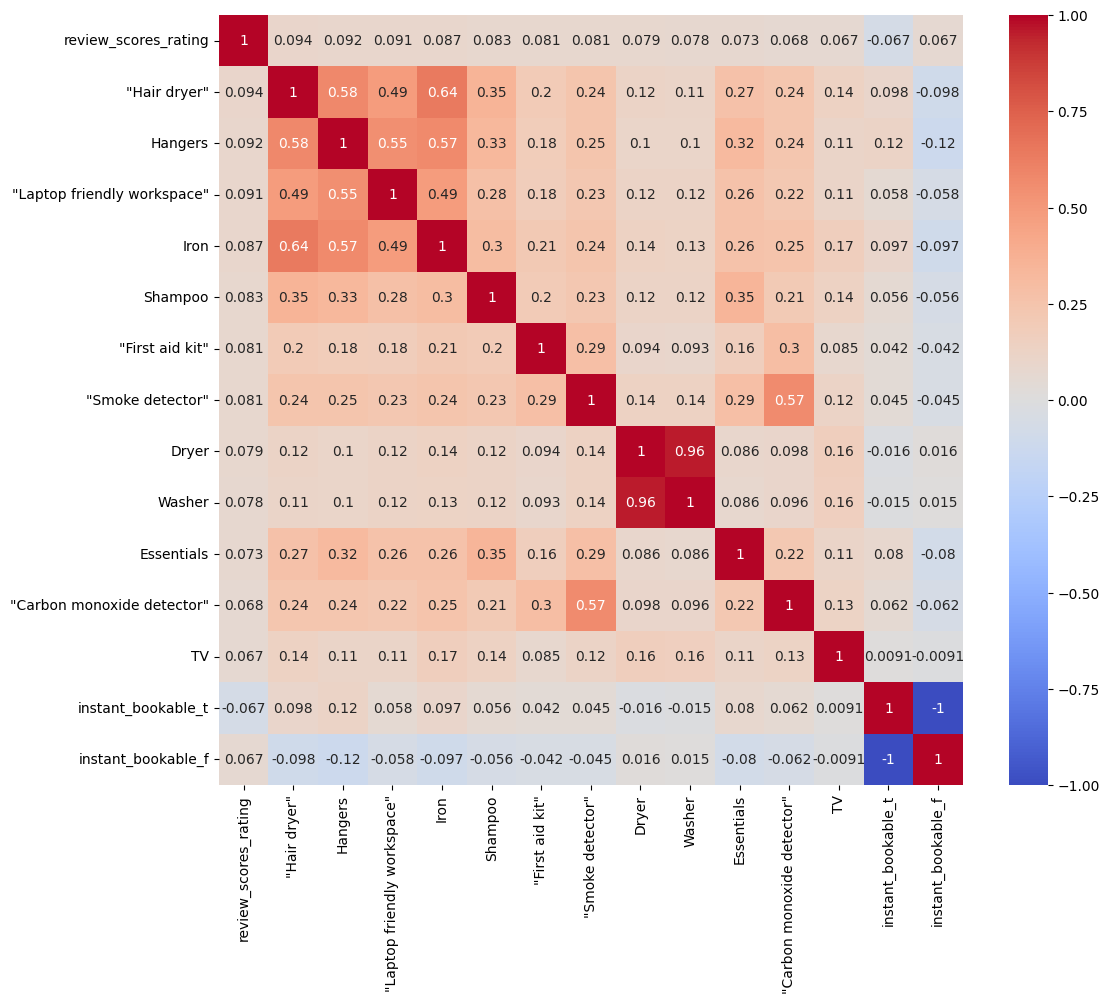

In [ ]:
df = pd.read_csv(
    'ogdataset.csv',
    encoding='latin1'
)
print(df.shape)
print(df.head())
print(df.info())
df = df[df["review_scores_rating"] > 0]
numeric_df = df.select_dtypes(include=['int64', 'float64'])
target = "review_scores_rating"
correlations = numeric_df.corr()[target].sort_values(ascending=False)

print(correlations)
selected_features = correlations[abs(correlations) > 0.05]

print(selected_features)

import matplotlib.pyplot as plt
import seaborn as sns

top_features = correlations.abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(12,10))
sns.heatmap(df[top_features].corr(), annot=True, cmap="coolwarm")
plt.show()
selected_features = [
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'cleaning_fee',
    'host_response_rate',
    'room_type_Entire home/apt',
    'room_type_Private room',
    'instant_bookable_t',
    '"Air conditioning"',
    '"Coffee maker"',
    '"Cooking basics"',
    '"Family/kid friendly"',
    '"Free parking on premises"',
    '"Hot water"',
    '"Private entrance"',
    '"Self Check-In"',
    '"Wireless Internet"',
    'Kitchen',
    'longitude',
    'latitude',
    '"Hair dryer"',
    '"Laptop friendly workspace"',
    'log_price',
    'Iron',
    'Shampoo',
    'Hangers',
    'Dryer',
    'Washer',
    '"First aid kit"',
    'Essentials',
    '"Smoke detector"',
    'TV'
]

final_columns = selected_features + ['review_scores_rating']

processed_df = df[final_columns]
processed_df = processed_df.dropna()
processed_df.to_csv("processed_airbnb.csv", index=False)
#files.download("processed_airbnb.csv")

Creating a csv called processed_airbnb_all_reviews.csv where it is our filtered feature but we also included reviews where there may be 0 or NA

In [ ]:
df = pd.read_csv(
    'ogdataset.csv',
    encoding='latin1'
)

df["review_scores_rating"] = pd.to_numeric(
    df["review_scores_rating"],
    errors="coerce"
)

df = df[df["review_scores_rating"].notna()]

selected_features = [
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'cleaning_fee',
    'host_response_rate',
    'room_type_Entire home/apt',
    'room_type_Private room',
    'instant_bookable_t',
    '"Air conditioning"',
    '"Coffee maker"',
    '"Cooking basics"',
    '"Family/kid friendly"',
    '"Free parking on premises"',
    '"Hot water"',
    '"Private entrance"',
    '"Self Check-In"',
    '"Wireless Internet"',
    'Kitchen',
    'longitude',
    'latitude',
    '"Hair dryer"',
    '"Laptop friendly workspace"',
    'log_price',
    'Iron',
    'Shampoo',
    'Hangers',
    'Dryer',
    'Washer',
    '"First aid kit"',
    'Essentials',
    '"Smoke detector"',
    'TV'
]

final_columns = selected_features + ['review_scores_rating']

processed_df = df[final_columns].copy()

feature_columns = [
    col for col in processed_df.columns
    if col != 'review_scores_rating'
]

processed_df[feature_columns] = processed_df[feature_columns].fillna(0)

print("Rows with ratings:", (processed_df["review_scores_rating"] > 0).sum())
print("Rows with no reviews:", (processed_df["review_scores_rating"] == 0).sum())

processed_df.to_csv(
    "processed_airbnb_all_reviews.csv",
    index=False
)

#files.download("processed_airbnb_all_reviews.csv")

Rows with ratings: 19741
Rows with no reviews: 5717


# LINEAR REGRESSION

Training the model based on the rows that do have reviews, dropping those that have no reviews (0)
Calculate MSE and R²

In [ ]:
df = pd.read_csv(
    'processed_airbnb_all_reviews.csv'
)


df['review_scores_rating'] = pd.to_numeric(
    df['review_scores_rating'],
    errors='coerce'
)

rated_df = df[df['review_scores_rating'] > 0].copy()


unrated_df = df[df['review_scores_rating'] == 0].copy()

print("Rows with ratings:", len(rated_df))
print("Rows with no reviews:", len(unrated_df))

X = rated_df.drop(columns=['review_scores_rating'])
y = rated_df['review_scores_rating']


X = pd.get_dummies(X)

X = X.fillna(0)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("MSE:", mse)
print("R²:", r2)



Rows with ratings: 19741
Rows with no reviews: 5717
MSE: 61.97536910926795
R²: 0.03818120963767002


Using the trained model to predict all review scores including the calculated error

In [ ]:
final_model = LinearRegression()
final_model.fit(X, y)

rated_df['predicted_review_score'] = final_model.predict(X)

rated_df['prediction_error'] = abs(
    rated_df['review_scores_rating']
    - rated_df['predicted_review_score']
)

if len(unrated_df) > 0:

    X_unrated = unrated_df.drop(columns=['review_scores_rating'])

    X_unrated = pd.get_dummies(X_unrated)

    X, X_unrated = X.align(
        X_unrated,
        join='left',
        axis=1,
        fill_value=0
    )

    X_unrated = X_unrated.fillna(0)

    unrated_predictions = final_model.predict(X_unrated)

    unrated_df['predicted_review_score'] = unrated_predictions
    unrated_df['prediction_error'] = np.nan

else:
    unrated_df['predicted_review_score'] = np.nan

final_df = pd.concat([rated_df, unrated_df])

final_df = final_df.sort_index()


final_df['final_review_score'] = final_df['review_scores_rating']

final_df.loc[
    final_df['review_scores_rating'] == 0,
    'final_review_score'
] = final_df['predicted_review_score']


display(
    final_df[
        [
            'review_scores_rating',
            'predicted_review_score',
            'prediction_error',
            'final_review_score'
        ]
    ].head(20)
)


,review_scores_rating,predicted_review_score,prediction_error,final_review_score
0,97.0,94.714737,2.285263,97.000000
1,80.0,95.576362,15.576362,80.000000
2,100.0,94.697232,5.302768,100.000000
3,94.0,95.205193,1.205193,94.000000
4,0.0,94.915263,NaN,94.915263
5,98.0,95.149681,2.850319,98.000000
6,97.0,92.291886,4.708114,97.000000
7,93.0,93.098216,0.098216,93.000000
8,92.0,95.720644,3.720644,92.000000
9,0.0,94.063744,NaN,94.063744


Generating scatterplot to show predicted vs actual review scores

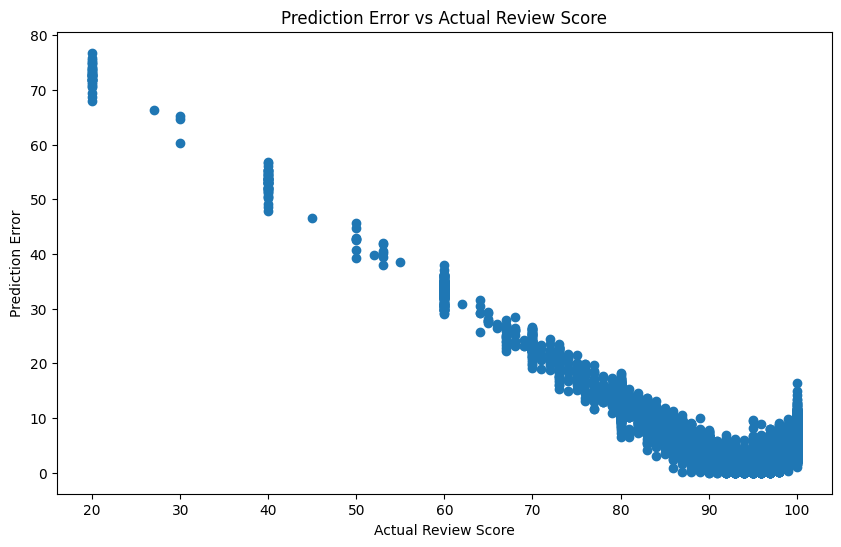

In [ ]:
rated_only = final_df[
    final_df['review_scores_rating'] > 0
]

plt.figure(figsize=(10, 6))

plt.scatter(
    rated_only['review_scores_rating'],
    rated_only['prediction_error']
)

plt.xlabel("Actual Review Score")
plt.ylabel("Prediction Error")
plt.title("Prediction Error vs Actual Review Score")

plt.show()

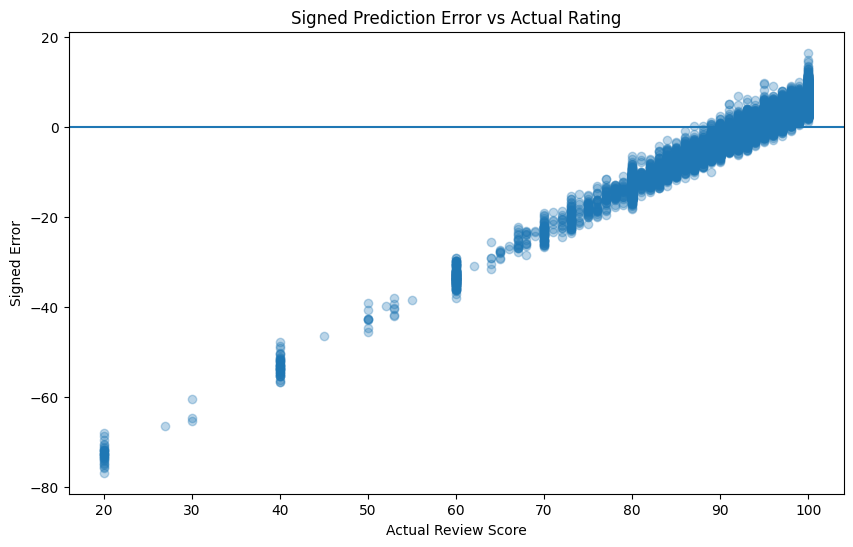

In [ ]:
# below 0 = model predicted too high
# above 0 = model predicted too low
# near 0 = accurate prediction

rated_df['signed_error'] = (
    rated_df['review_scores_rating']
    - rated_df['predicted_review_score']
)
plt.figure(figsize=(10,6))

plt.scatter(
    rated_df['review_scores_rating'],
    rated_df['signed_error'],
    alpha=0.3
)

plt.axhline(y=0)

plt.xlabel("Actual Review Score")
plt.ylabel("Signed Error")
plt.title("Signed Prediction Error vs Actual Rating")

plt.show()

We decided to move on from linear regression due to its simplicity and its performance on training and testing.

#POLYNOMIAL REGRESSION

Polynomial Degree 2
Train MSE: 57.6632
Test MSE: 61.5900
Train R2: 0.0911
Test R2: 0.0442


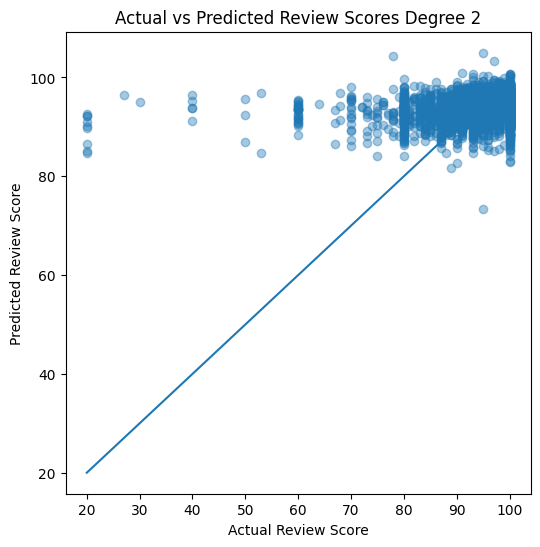

Polynomial Degree 3
Train MSE: 38.5652
Test MSE: 370.2656
Train R2: 0.3922
Test R2: -4.7463


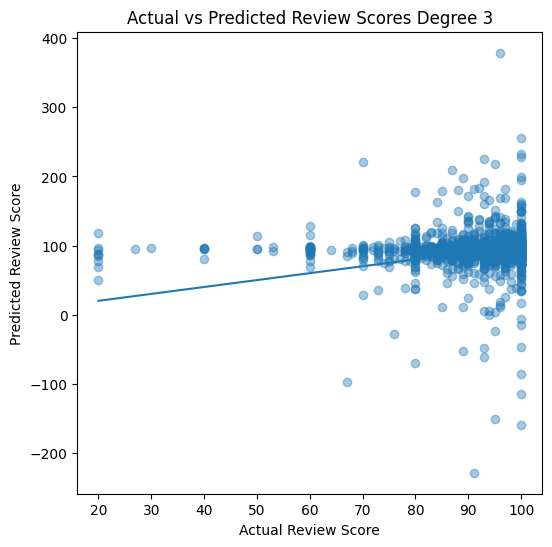

In [ ]:
def polynomial_regression(degree):
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(
            degree=degree,
            include_bias=False,
            interaction_only=True
        )),
        ("ridge", Ridge(alpha=1.0))
    ])

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    print(f"Polynomial Degree {degree}")
    print(f"Train MSE: {mean_squared_error(y_train, y_train_pred):.4f}")
    print(f"Test MSE: {mean_squared_error(y_test, y_test_pred):.4f}")
    print(f"Train R2: {r2_score(y_train, y_train_pred):.4f}")
    print(f"Test R2: {r2_score(y_test, y_test_pred):.4f}")

    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, y_test_pred, alpha=0.4)
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()]
    )
    plt.xlabel("Actual Review Score")
    plt.ylabel("Predicted Review Score")
    plt.title(f"Actual vs Predicted Review Scores Degree {degree}")
    plt.show()
    return model

poly2_model = polynomial_regression(2)
poly3_model = polynomial_regression(3)

Try with L2 Ridge

Polynomial Degree 2
Train MSE: 1345.3828
Test MSE: 1335.9665
Train R2: 0.1580
Test R2: 0.1381


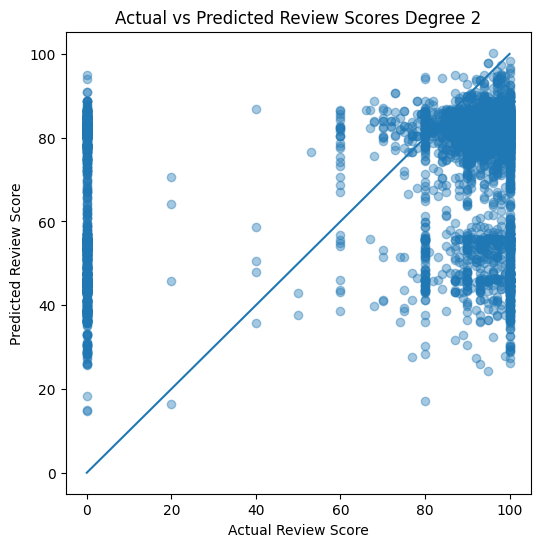

Polynomial Degree 3
Train MSE: 1334.2751
Test MSE: 1347.6127
Train R2: 0.1650
Test R2: 0.1306


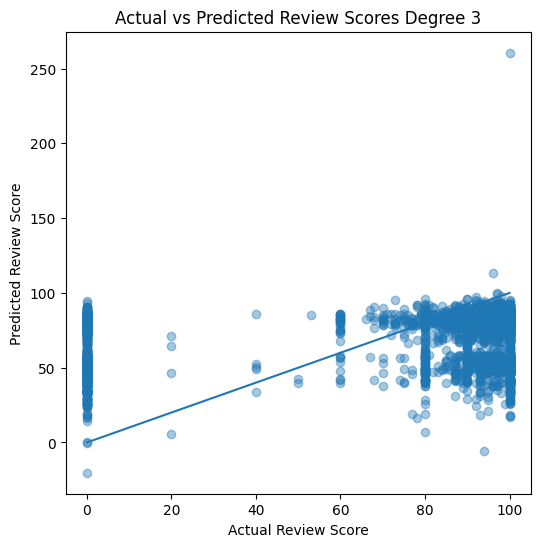

In [ ]:
def ridge_model(degree):
  model = Pipeline([
      ("scaler", StandardScaler()),
      ("poly", PolynomialFeatures(degree=degree,include_bias=False,interaction_only=True)),
      ("ridge", Ridge(alpha=1))
  ])

  model.fit(X_train, y_train)

  y_train_pred = model.predict(X_train)
  y_test_pred = model.predict(X_test)

  train_mse = mean_squared_error(y_train, y_train_pred)
  test_mse = mean_squared_error(y_test, y_test_pred)
  train_r2 = r2_score(y_train, y_train_pred)
  test_r2 = r2_score(y_test, y_test_pred)

  print(f"Polynomial Degree {degree}")
  print(f"Train MSE: {train_mse:.4f}")
  print(f"Test MSE: {test_mse:.4f}")
  print(f"Train R2: {train_r2:.4f}")
  print(f"Test R2: {test_r2:.4f}")

  plt.figure(figsize=(6, 6))
  plt.scatter(y_test, y_test_pred, alpha=0.4)
  plt.plot(
      [y_test.min(), y_test.max()],
      [y_test.min(), y_test.max()]
  )
  plt.xlabel("Actual Review Score")
  plt.ylabel("Predicted Review Score")
  plt.title(f"Actual vs Predicted Review Scores Degree {degree}")
  plt.show()

  return model

ridge2_model = ridge_model(2)
ridge3_model = ridge_model(3)

Find the features with biggest contribution and form a smaller set of features

In [ ]:
feature_names = ridge2_model.named_steps["poly"].get_feature_names_out(X.columns)

coefficients = ridge2_model.named_steps["ridge"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["Abs_Coefficient"] = np.abs(coef_df["Coefficient"])

coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

top_features = coef_df.head(15)

print(top_features)


                                          Feature  Coefficient  \
255                  room_type_Private room Dryer     2.208598   
256                 room_type_Private room Washer    -2.028520   
230               room_type_Entire home/apt Dryer     1.828956   
231              room_type_Entire home/apt Washer    -1.787965   
204                      host_response_rate Dryer    -1.006869   
3                                            beds    -0.959032   
490                               latitude Washer     0.813426   
2                                        bedrooms     0.811364   
470                            longitude latitude    -0.790203   
205                     host_response_rate Washer     0.780515   
187             host_response_rate "Coffee maker"    -0.766304   
10                                 "Coffee maker"     0.746607   
150                                   beds Washer     0.735907   
243     room_type_Private room "Private entrance"    -0.717153   
218  room_

In [ ]:
smaller_features = [
    'host_response_rate',
    'accommodates',

    'latitude',
    'longitude',
    'log_price',
    'beds',
    'room_type_Private room',
    'Dryer',
    'Washer',
    '"Cooking basics"',
    '"Coffee maker"'
]

X = df[smaller_features]
y = df['review_scores_rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
ridge2_model = ridge_model(2)
ridge3_model = ridge_model(3)


Polynomial Degree 2
Train MSE: 1345.3828
Test MSE: 1335.9665
Train R2: 0.1580
Test R2: 0.1381
Polynomial Degree 3
Train MSE: 1334.2751
Test MSE: 1347.6127
Train R2: 0.1650
Test R2: 0.1306


# NEURAL NETWORK

Start with a simple Neural Network with 2 hidden layers. First have 64 nodes and second have 32, output1 with sigmoid activation function, then scale the output to be between 0 to 100

In [ ]:
df = pd.read_csv("processed_airbnb.csv", encoding="latin1")

X = df.drop(columns=["review_scores_rating"])
y = df["review_scores_rating"]
y_scaled = y / 100.0 #scale down to be between 0 to 1 since we output sigmoid which is 0 to 1

X_train, X_test, y_train, y_test = train_test_split(X, y_scaled, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mse"]
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)
y_train_pred = model.predict(X_train_scaled).flatten()
y_test_pred = model.predict(X_test_scaled).flatten()

y_train_pred = y_train_pred * 100
y_test_pred = y_test_pred * 100
y_train_actual = y_train * 100
y_test_actual = y_test * 100
#scale the output values back to between 0 and 100


print("Train MSE:", mean_squared_error(y_train_actual, y_train_pred))
print("Test MSE:", mean_squared_error(y_test_actual, y_test_pred))

print("Train RMSE:", np.sqrt(mean_squared_error(y_train_actual, y_train_pred)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test_actual, y_test_pred)))

print("Train R2:", r2_score(y_train_actual, y_train_pred))
print("Test R2:", r2_score(y_test_actual, y_test_pred))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0124 - mse: 0.0124 - val_loss: 0.0058 - val_mse: 0.0058
Epoch 2/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0063 - mse: 0.0063 - val_loss: 0.0055 - val_mse: 0.0055
Epoch 3/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0061 - mse: 0.0061 - val_loss: 0.0055 - val_mse: 0.0055
Epoch 4/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0060 - mse: 0.0060 - val_loss: 0.0054 - val_mse: 0.0054
Epoch 5/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0059 - mse: 0.0059 - val_loss: 0.0054 - val_mse: 0.0054
Epoch 6/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0058 - mse: 0.0058 - val_loss: 0.0055 - val_mse: 0.0055
Epoch 7/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0058 - mse: 0.0058 - val_loss: 0.0054 - val_mse: 0.0054
Epoch 8/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0057 - mse: 0.0057 - val_loss: 0.0054 - val_mse: 0.0054
Epoch 9/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

Use dropout to prevent overdependence one any singular nodes

In [ ]:
model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(32, activation="relu"),

    Dense(1, activation="sigmoid")
])
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mse"]
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)
y_train_pred = model.predict(X_train_scaled).flatten()
y_test_pred = model.predict(X_test_scaled).flatten()

y_train_pred = y_train_pred * 100
y_test_pred = y_test_pred * 100

y_train_actual = y_train * 100
y_test_actual = y_test * 100


print("Train MSE:", mean_squared_error(y_train_actual, y_train_pred))
print("Test MSE:", mean_squared_error(y_test_actual, y_test_pred))

print("Train RMSE:", np.sqrt(mean_squared_error(y_train_actual, y_train_pred)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test_actual, y_test_pred)))

print("Train R2:", r2_score(y_train_actual, y_train_pred))
print("Test R2:", r2_score(y_test_actual, y_test_pred))


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1148/1148 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0080 - mse: 0.0080 - val_loss: 0.0059 - val_mse: 0.0059
Epoch 2/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0063 - mse: 0.0063 - val_loss: 0.0060 - val_mse: 0.0060
Epoch 3/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0061 - mse: 0.0061 - val_loss: 0.0060 - val_mse: 0.0060
Epoch 4/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0060 - mse: 0.0060 - val_loss: 0.0068 - val_mse: 0.0068
Epoch 5/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0060 - mse: 0.0060 - val_loss: 0.0059 - val_mse: 0.0059
Epoch 6/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0059 - mse: 0.0059 - val_loss: 0.0060 - val_mse: 0.0060
Epoch 7/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0059 - mse: 0.0059 - val_loss: 0.0061 - val_mse: 0.0061
Epoch 8/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0059 - mse: 0.0059 - val_loss: 0.0060 - val_mse: 0.0060
Epoch 9/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 4

Add in L2 ridge and Batch Normalization to help with the weight distribution. While this approach had worse MSE, the overfitting problem is solved.

In [ ]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import BatchNormalization

model = Sequential([
    Dense(128,activation="relu",kernel_regularizer=l2(0.001),input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu", kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation="relu", kernel_regularizer=l2(0.001)),
    BatchNormalization(),

    Dense(1, activation="sigmoid")
])
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mse"]
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)
y_train_pred = model.predict(X_train_scaled).flatten()
y_test_pred = model.predict(X_test_scaled).flatten()

y_train_pred = y_train_pred * 100
y_test_pred = y_test_pred * 100

y_train_actual = y_train * 100
y_test_actual = y_test * 100


print("Train MSE:", mean_squared_error(y_train_actual, y_train_pred))
print("Test MSE:", mean_squared_error(y_test_actual, y_test_pred))

print("Train RMSE:", np.sqrt(mean_squared_error(y_train_actual, y_train_pred)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test_actual, y_test_pred)))

print("Train R2:", r2_score(y_train_actual, y_train_pred))
print("Test R2:", r2_score(y_test_actual, y_test_pred))


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1148/1148 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - loss: 0.0914 - mse: 0.0261 - val_loss: 0.0138 - val_mse: 0.0060
Epoch 2/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0091 - mse: 0.0063 - val_loss: 0.0073 - val_mse: 0.0060
Epoch 3/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0074 - mse: 0.0062 - val_loss: 0.0070 - val_mse: 0.0059
Epoch 4/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0073 - mse: 0.0062 - val_loss: 0.0070 - val_mse: 0.0060
Epoch 5/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0071 - mse: 0.0062 - val_loss: 0.0068 - val_mse: 0.0061
Epoch 6/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0070 - mse: 0.0062 - val_loss: 0.0069 - val_mse: 0.0061
Epoch 7/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0069 - mse: 0.0062 - val_loss: 0.0069 - val_mse: 0.0061
Epoch 8/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0069 - mse: 0.0062 - val_loss: 0.0068 - val_mse: 0.0061
Epoch 9/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 

Deep neural network containing 3 hidden layers. The hidden layers have 128, 64 and 32 neurons. Batch normalization and dropout regularization are applied between layers to improve training stability and reduce overfitting. The output layer contains 1 neuron with a sigmoid activation function and then scale the output to be between 0 to 100

In [ ]:


model = Sequential([
    Dense(128, activation="relu", kernel_regularizer=l2(0.001),
          input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu", kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation="relu", kernel_regularizer=l2(0.001)),
    BatchNormalization(),

    Dense(1, activation="sigmoid")
])
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mse"]
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

y_train_pred = model.predict(X_train_scaled).flatten()
y_test_pred = model.predict(X_test_scaled).flatten()

y_train_pred = y_train_pred * 100
y_test_pred = y_test_pred * 100

y_train_actual = y_train * 100
y_test_actual = y_test * 100


print("Train MSE:", mean_squared_error(y_train_actual, y_train_pred))
print("Test MSE:", mean_squared_error(y_test_actual, y_test_pred))

print("Train RMSE:", np.sqrt(mean_squared_error(y_train_actual, y_train_pred)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test_actual, y_test_pred)))

print("Train R2:", r2_score(y_train_actual, y_train_pred))
print("Test R2:", r2_score(y_test_actual, y_test_pred))

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


395/395 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.1988 - mse: 0.0672 - val_loss: 0.0925 - val_mse: 0.0060
Epoch 2/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0615 - mse: 0.0071 - val_loss: 0.0353 - val_mse: 0.0056
Epoch 3/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0241 - mse: 0.0067 - val_loss: 0.0147 - val_mse: 0.0056
Epoch 4/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0120 - mse: 0.0065 - val_loss: 0.0087 - val_mse: 0.0055
Epoch 5/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0084 - mse: 0.0064 - val_loss: 0.0067 - val_mse: 0.0054
Epoch 6/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0076 - mse: 0.0064 - val_loss: 0.0065 - val_mse: 0.0055
Epoch 7/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0073 - mse: 0.0063 - val_loss: 0.0063 - val_mse: 0.0054
Epoch 8/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0069 - mse: 0.0062 - val_loss: 0.0059 - val_mse: 0.0054
Epoch 9/100
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: